In [1]:
#2021.10.12. TUE
#Team_SmokeFree

## GeoPandas Polygon Calculation(Overlay) Practice
#00.패키지 호출
import warnings 
import pandas as pd 
import geopandas as gpd 
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

#00-1. warning message ignore 
warnings.filterwarnings(action='ignore')

#00-2. 시각화 옵션 설정하기.  
%matplotlib inline
plt.rcParams["font.family"] = 'D2Coding'


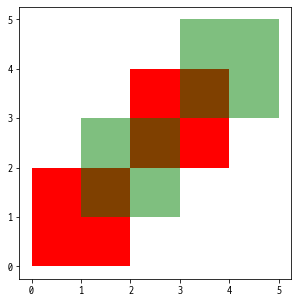

In [2]:
#01. 폴리곤 및 지오데이터프레임 정의하기.  
polys1 = gpd.GeoSeries([Polygon([(0,0), (2,0), (2,2), (0,2)]),
                               Polygon([(2,2), (4,2), (4,4), (2,4)])])
polys2 = gpd.GeoSeries([Polygon([(1,1), (3,1), (3,3), (1,3)]),
                               Polygon([(3,3), (5,3), (5,5), (3,5)])])
df1 = gpd.GeoDataFrame({'geometry': polys1, 'df1':[1,2]})
df2 = gpd.GeoDataFrame({'geometry': polys2, 'df2':[1,2]})

#02. 지오데이터프레임 시각화하기. 
ax = df1.plot(color='red', figsize=(5,5))
df2.plot(ax=ax, color='green', alpha=0.5)
plt.show()

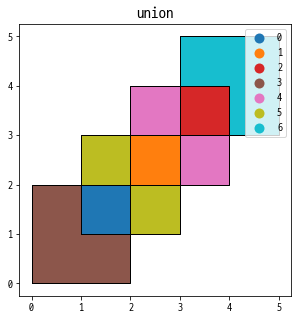

In [3]:
#03. overlay:union 적용하기. 
res_union = gpd.overlay(df1, df2, how='union')
#print(res_union)
res_union = res_union.reset_index()
res_union['index'] = res_union['index'].astype(str)

ax = res_union.plot(column='index', legend=True, figsize=(5,5))
df1.plot(ax=ax, facecolor='none', edgecolor='k')
df2.plot(ax=ax, facecolor='none', edgecolor='k')
plt.title("union", fontsize=15)
plt.show()

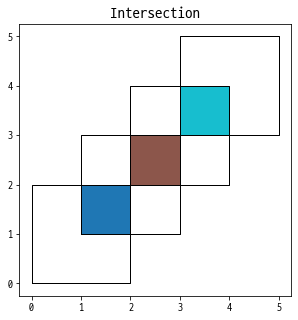

In [4]:
#04. overlay:union 적용하기. 
res_intersection = gpd.overlay(df1, df2, how='intersection')
#print(res_intersection)

ax = res_intersection.plot(figsize=(5,5),cmap='tab10')
df1.plot(ax=ax, facecolor='none', edgecolor='k')
df2.plot(ax=ax, facecolor='none', edgecolor='k')
plt.title("Intersection", fontsize=15)
plt.show()

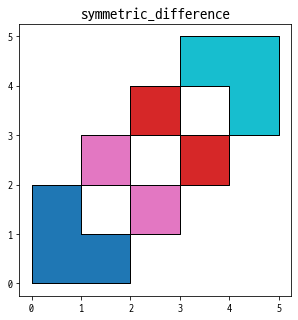

In [5]:
#05. overlay:symmetric_difference 적용하기. 
printres_symdiff = gpd.overlay(df1, df2, how='symmetric_difference')
#print(printres_symdiff)

ax = printres_symdiff.plot(figsize=(5,5),cmap='tab10')
df1.plot(ax=ax, facecolor='none', edgecolor='k')
df2.plot(ax=ax, facecolor='none', edgecolor='k')
plt.title("symmetric_difference", fontsize=15)
plt.show()

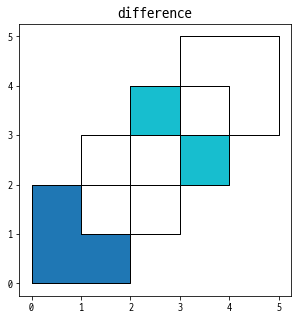

In [6]:
#06. overlay:difference 적용하기. 
res_difference = gpd.overlay(df1, df2, how='difference')
#print(res_difference)

ax = res_difference.plot(figsize=(5,5),cmap='tab10')
df1.plot(ax=ax, facecolor='none', edgecolor='k')
df2.plot(ax=ax, facecolor='none', edgecolor='k')
plt.title("difference", fontsize=15)
plt.show()